In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import csv
from scipy import spatial
from sko.GA import GA_TSP
from sko.PSO import PSO_TSP

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)

In [13]:
def DistanceRounded(p, q):
    """Euclidean distance rounded to the nearest integer."""
    return int(np.hypot(p[0] - q[0], p[1] - q[1]) + 0.5)

def TourLength(T, dist_matrix):
    """Computes the total length of a tour using the distance matrix."""
    length = 0
    num_cities = len(T)
    for i in range(num_cities):
        length += dist_matrix[T[i], T[(i + 1) % num_cities]]
    return length

def ReadTsp(fn):
    """Reads a .tsp file and returns city coordinates and best known length."""
    cities = []
    best = 0.0
    with open(fn + ".tsp", "rt") as f:
        reader = csv.reader(f, delimiter=" ", skipinitialspace=True)
        coordinates = False
        index = 0
        for row in reader:
            if not row or row[0] == "EOF": break
            if coordinates:
                cities.append((float(row[1]), float(row[2]), index))
                index += 1
            elif row[0] in ["BEST:", "OPTIMUM:", "BEST", "OPTIMUM"]:
                best = float(row[-1])
            elif row[0] == "NODE_COORD_SECTION":
                coordinates = True
    return cities, best

def PlotTour(cities, tour, title="TSP Tour"):
    """Visualizes the tour path."""
    coords = np.array([(cities[i][0], cities[i][1]) for i in tour])
    coords = np.vstack([coords, coords[0]]) # Close the loop
    plt.figure(figsize=(8, 8))
    plt.plot(coords[:, 0], coords[:, 1], 'o-r', markersize=5)
    plt.title(title)
    plt.show()

In [14]:
class Custom_GA_TSP(GA_TSP):
    def __init__(self, func, n_dim, size_pop=50, max_iter=200, prob_mut=0.001, tourn_size=3):
        # Inicialitzem la classe pare
        super().__init__(func=func, n_dim=n_dim, size_pop=size_pop, max_iter=max_iter, prob_mut=prob_mut)
        self.tourn_size = tourn_size

    def selection(self):
        # Selecció per torneig personalitzada:
        # self.Y conté les distàncies de cada ruta (com més baix, millor)
        sel_index = np.random.randint(0, self.size_pop, size=(self.size_pop, self.tourn_size))
        y_candidates = self.Y[sel_index]
        
        # Agafem el guanyador de cada torneig (el que té la distància mínima)
        winner_indices = np.argmin(y_candidates, axis=1)
        final_sel_index = sel_index[np.arange(self.size_pop), winner_indices]
        
        # Actualitzem la població amb els guanyadors
        self.Chrom = self.Chrom[final_sel_index, :]
        return self.Chrom

In [15]:
filename = 'berlin52'
theCities, bestLength = ReadTsp(filename)
num_cities = len(theCities)

# Build Distance Matrix
points_coordinate = np.array([(c[0], c[1]) for c in theCities])
distance_matrix = spatial.distance.cdist(points_coordinate, points_coordinate, metric='euclidean')
# Round values for standard TSPLIB evaluation
distance_matrix = np.rint(distance_matrix).astype(int)

# Fitness Function for sko
def cal_total_distance(routine):
    return TourLength(routine, distance_matrix)

In [16]:
def run_tsp_experiment(algo_class, rounds=10, **params):
    final_results = []
    all_histories = []
    
    start_time = time.time()
    for r in range(rounds):
        model = algo_class(func=cal_total_distance, n_dim=num_cities, **params)
        best_x, best_y = model.run()
        final_results.append(best_y[0])
        if isinstance(model, PSO_TSP):
            all_histories.append(model.gbest_y_hist)
        else:
            all_histories.append(model.all_history_Y)
        
    avg_history = np.mean(all_histories, axis=0).flatten()
    std_history = np.std(all_histories, axis=0).flatten()
    
    return {
        'avg': np.mean(final_results),
        'min': np.min(final_results),
        'std': np.std(final_results),
        'history': avg_history,
        'std_history': std_history,
        'time': (time.time() - start_time) / rounds
    }

In [17]:
# Parameters to test
pop_sizes = [50, 100, 200]
max_iter = 2000
results_pso = []
master_histories = {}

print(f"Starting PSO experiments on {filename}...")
for pop in pop_sizes:
    res = run_tsp_experiment(PSO_TSP, rounds=10, size_pop=pop, max_iter=max_iter)
    results_pso.append({
        'Pop': pop, 'Avg Fit': res['avg'], 'Min Fit': res['min'],
         'Std Dev': res['std'], 'Time/Round': res['time']
    })
    master_histories[f"PSO Pop {pop}"] = res

df_pso = pd.DataFrame(results_pso)


optimal = 7542
df_pso['Avg Error %'] = ((df_pso['Avg Fit'] - optimal) / optimal) * 100
df_pso['Min Error %'] = ((df_pso['Min Fit'] - optimal) / optimal) * 100
print(df_pso)

Starting PSO experiments on berlin52...
   Pop  Avg Fit  Min Fit     Std Dev  Time/Round  Avg Error %  Min Error %
0   50   8154.5   7764.0  252.625909    7.603829     8.121188     2.943516
1  100   8146.5   7846.0  227.869809   13.515571     8.015115     4.030761
2  200   7776.2   7542.0  234.131074   26.246325     3.105277     0.000000


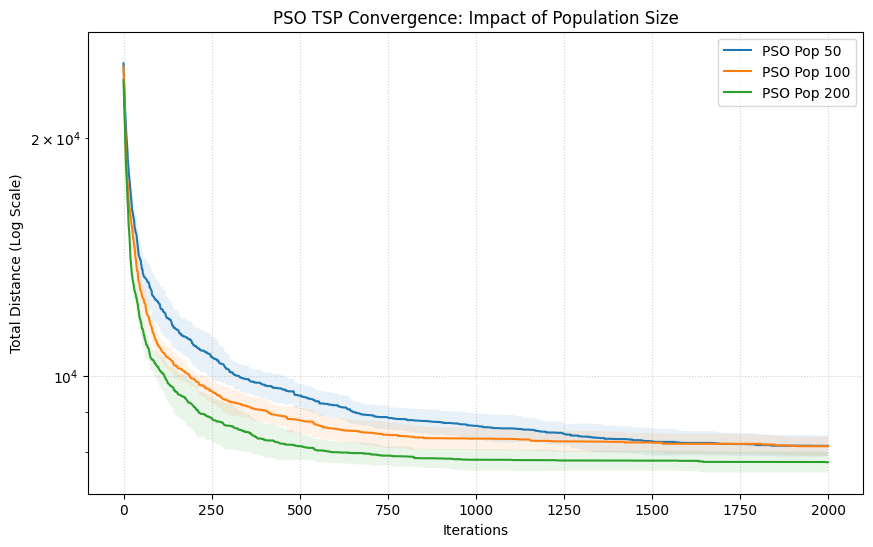

In [18]:
plt.figure(figsize=(10, 6))
for label, data in master_histories.items():
    iters = np.arange(len(data['history']))
    plt.plot(iters, data['history'], label=label)
    plt.fill_between(iters, data['history'] - data['std_history'], 
                     data['history'] + data['std_history'], alpha=0.1)

plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Total Distance (Log Scale)')
plt.title('PSO TSP Convergence: Impact of Population Size')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [22]:
# Parameters to test
num_iter = [500, 1000, 2000]
fixed_pop = 200
results_pso = []
master_histories = {}

print(f"Starting PSO experiments on {filename}...")
for iter in num_iter:
    res = run_tsp_experiment(PSO_TSP, rounds=10, size_pop=fixed_pop, max_iter=iter)
    results_pso.append({
        'Iter': iter, 'Avg Fit': res['avg'], 'Min Fit': res['min'],
         'Std Dev': res['std'], 'Time/Round': res['time']
    })
    master_histories[f"PSO Iter {iter}"] = res

df_pso = pd.DataFrame(results_pso)


optimal = 7542
df_pso['Avg Error %'] = ((df_pso['Avg Fit'] - optimal) / optimal) * 100
df_pso['Min Error %'] = ((df_pso['Min Fit'] - optimal) / optimal) * 100
print(df_pso)

Starting PSO experiments on berlin52...
   Iter  Avg Fit  Min Fit     Std Dev  Time/Round  Avg Error %  Min Error %
0   500   8105.1   7661.0  301.311284    5.998987     7.466189     1.577831
1  1000   7863.5   7542.0  189.951178   11.755405     4.262795     0.000000
2  2000   7883.9   7542.0  242.309079   23.485657     4.533280     0.000000


# **Genetic Algorithm experiments**

In [20]:
print("Running GA Comparison...")
results_ga = []
pop_sizes = [50, 100, 200]

for pop in pop_sizes:
    res_ga = run_tsp_experiment(Custom_GA_TSP, rounds=10, size_pop=pop, max_iter=2000, prob_mut=1, tourn_size=3)
    results_ga.append({
        'Pop': pop, 'Avg Fit': res_ga['avg'], 'Min Fit': res_ga['min'],
         'Std Dev': res_ga['std'], 'Time/Round': res_ga['time']
    })

df_ga = pd.DataFrame(results_ga)


optimal = 7542
df_ga['Avg Error %'] = ((df_ga['Avg Fit'] - optimal) / optimal) * 100
df_ga['Min Error %'] = ((df_ga['Min Fit'] - optimal) / optimal) * 100
print(df_ga)


Running GA Comparison...
   Pop  Avg Fit  Min Fit     Std Dev  Time/Round  Avg Error %  Min Error %
0   50   8095.2     7618  300.519151    5.061666     7.334924     1.007690
1  100   8159.5     7731  217.658563   10.385853     8.187483     2.505967
2  200   8039.3     7542  239.275594   20.406382     6.593742     0.000000


In [ ]:
comparison_data = [
    {'Algorithm': 'PSO (Pop 200)', 'Avg Fit': master_histories['PSO Pop 200']['avg'], 'Min Fit': master_histories['PSO Pop 200']['min']},
    {'Algorithm': 'GA (Pop 200)', 'Avg Fit': res_ga['avg'], 'Min Fit': res_ga['min']}
]
print(pd.DataFrame(comparison_data))